**Objetivo específico 3:** Seleccionar las proteínas candidatas con mayor relevancia pronóstica identificadas por los modelos de ML con la finalidad de proponer su validación y futura aplicación clínica como biomarcadores.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

!pip install shap -q
import shap

import matplotlib.pyplot as plt

In [ ]:
# subir dataset sintetico creado en objetivo especifico 1
subida = files.upload()
archivo = list(subida.keys())[0]

dataset_final = pd.read_csv(archivo)

print("Archivo subido ok ✅")
print("Filas:", dataset_final.shape[0], " Columnas:", dataset_final.shape[1])

Saving dataset_sintetico_pbmc.csv to dataset_sintetico_pbmc.csv
Archivo subido ok ✅
Filas: 83  Columnas: 194


In [ ]:
# fijar semilla para reproducibilidad
np.random.seed(42)
print("Semilla fijada ✅")

Semilla fijada ✅


In [ ]:
# filtrar dataset sintetico solo para C/A y C/S
proteinas = dataset_final.columns[:-2]

dataset_obj3 = dataset_final[dataset_final["Grupo"].isin(["C/A", "C/S"])]

X = dataset_obj3[proteinas]
y = dataset_obj3["Grupo"]

print("Dataset filtrado ✅")
print("X:", X.shape, " y:", y.shape)
print(y.value_counts())

Dataset filtrado ✅
X: (53, 192)  y: (53,)
Grupo
C/S    28
C/A    25
Name: count, dtype: int64


In [ ]:
# separar en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Entrenamiento:", X_train.shape, " Validacion:", X_test.shape)

Entrenamiento: (42, 192)  Validacion: (11, 192)


In [ ]:
# estandarizar proteinas
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

print("Escalado listo ✅")

Escalado listo ✅


In [ ]:
# reentrenar el modelo ganador (regresion logistica)
modelo_final = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
modelo_final.fit(X_train_esc, y_train)

print("Modelo final reentrenado ✅")

Modelo final reentrenado ✅


In [ ]:
# mostrar 10 proteinas que mas afectan el desempeño del modelo
# cuando se desordenan
resultado_permutacion = permutation_importance(
    modelo_final, X_test_esc, y_test,
    n_repeats=30, random_state=42, scoring="roc_auc"
)

importancia_permutacion = pd.DataFrame({
    "Proteina": proteinas,
    "Importancia": resultado_permutacion.importances_mean
}).sort_values("Importancia", ascending=False)

print("Top 10 proteinas por importancia de permutacion:")
importancia_permutacion.head(10)

Top 10 proteinas por importancia de permutacion:


,Proteina,Importancia
136,"Mitochondrial carrier homolog 1, isoform 3_spo...",0.028889
29,"Actin, cytoplasmic 1_spot185",0.021111
2,"Actin, cytoplasmic 1_spot769",0.014444
124,"Keratin, type II cytoskeletal 1_spot738",0.013333
7,"Actin, cytoplasmic 1_spot642",0.012222
144,Fibrinogen alpha isoform 2_spot273,0.012222
152,POTE ankyrin domain F_spot261,0.011111
162,Ras-related protein Ral-B_spot718,0.010000
110,Heterogeneous nuclear ribonucleoprotein K_spot637,0.010000
173,Transcriptional repressor YY1_spot723,0.008889


In [ ]:
# calcular valores SHAP
explicador = shap.LinearExplainer(modelo_final, X_train_esc)
valores_shap = explicador.shap_values(X_test_esc)

print("Valores SHAP calculados ✅")
print("Forma de los valores SHAP:", valores_shap.shape)

Valores SHAP calculados ✅
Forma de los valores SHAP: (11, 192)


/tmp/ipykernel_4358/686259132.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap, X_test, feature_names=proteinas,


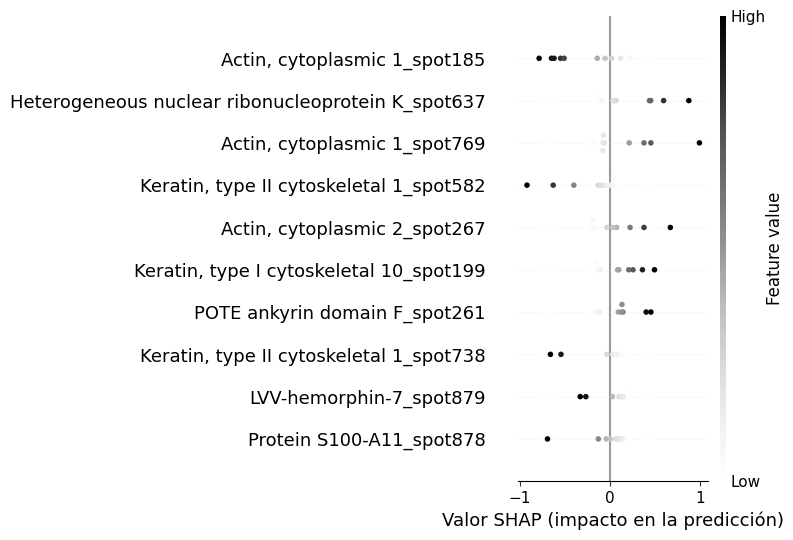

In [ ]:
# grafico resumen Figura SHAP
fig, ax = plt.subplots(figsize=(8,6))

shap.summary_plot(valores_shap, X_test, feature_names=proteinas,
                   max_display=10, show=False,
                   cmap=plt.get_cmap("Greys"))

plt.xlabel("Valor SHAP (impacto en la predicción)", color="black")
for texto in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    texto.set_color("black")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

#cbar = plt.gcf().axes[-1]
#cbar.set_ylabel("Valor de la proteína", color="black")

plt.tight_layout()
plt.savefig("figura_shap_resumen.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Importancia nativa (coeficientes de la regresión logística)
importancia_nativa = pd.DataFrame({
    "Proteina": proteinas,
    "Coeficiente": modelo_final.coef_[0]
})

importancia_nativa["Coeficiente_abs"] = importancia_nativa["Coeficiente"].abs()
importancia_nativa = importancia_nativa.sort_values("Coeficiente_abs", ascending=False)

print("Top 10 proteinas por coeficiente (importancia nativa):")
importancia_nativa.head(10)[["Proteina", "Coeficiente"]]

Top 10 proteinas por coeficiente (importancia nativa):


,Proteina,Coeficiente
121,"Keratin, type I cytoskeletal 9_spot863",0.274336
29,"Actin, cytoplasmic 1_spot185",-0.264112
72,Fibrinogen alpha chain 2_spot127,0.260770
79,Fibrinogen beta chain_spot195,0.238621
25,"Actin, cytoplasmic 1_spot781",0.238392
144,Fibrinogen alpha isoform 2_spot273,-0.237587
2,"Actin, cytoplasmic 1_spot769",0.237549
158,Pyruvate kinase M1/M2_spot169,0.232881
56,Annexin A1_spot373,-0.226104
154,Protein S100-A11_spot878,-0.224979


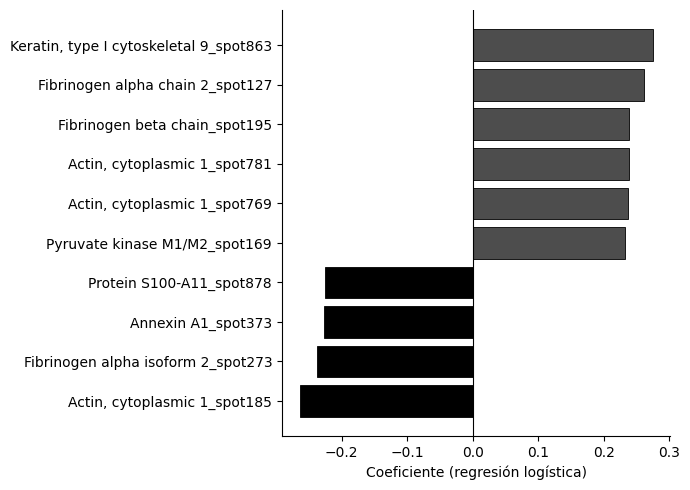

In [ ]:
# figura de coeficientes
top10_nativa = importancia_nativa.head(10).sort_values("Coeficiente")  # ordenado para graficar de abajo hacia arriba

fig, ax = plt.subplots(figsize=(7,5))

colores_barras = ["black" if c < 0 else "#4d4d4d" for c in top10_nativa["Coeficiente"]]
ax.barh(top10_nativa["Proteina"], top10_nativa["Coeficiente"], color=colores_barras, edgecolor="black", linewidth=0.6)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (regresión logística)", color="black")
ax.tick_params(colors="black")
for etiqueta in ax.get_xticklabels() + ax.get_yticklabels():
    etiqueta.set_color("black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig("figura_coeficientes_top10.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# cruzar rankinkg ML contra las proteínas más significativas del paper
# Subir de nuevo el table2.csv (la tabla original extraída del paper en la Fase 0)
subida = files.upload()
archivo_paper = list(subida.keys())[0]

# Como es un archivo .xlsx, usamos read_excel en vez de read_csv
tabla_paper = pd.read_excel(archivo_paper)

tabla_paper["Protein name"] = tabla_paper["Protein name"].fillna(method="ffill")
tabla_paper["p_valor"] = pd.to_numeric(tabla_paper["E value"], errors="coerce")

top_paper = tabla_paper.dropna(subset=["p_valor"]).sort_values("p_valor").head(15)

print("Top 15 proteinas mas significativas segun el paper (Garg et al., 2016):")
print(top_paper[["Protein name","p_valor"]])

proteinas_ml = set(importancia_permutacion.head(10)["Proteina"].str.split("_spot").str[0]) | \
               set(importancia_nativa.head(10)["Proteina"].str.split("_spot").str[0])

proteinas_paper = set(top_paper["Protein name"])

coincidencias = proteinas_ml & proteinas_paper
print()
print("Proteinas que coinciden entre tu ranking de ML y el top del paper:", coincidencias)

Saving tabla1.csv.xlsx to tabla1.csv (1).xlsx
Top 15 proteinas mas significativas segun el paper (Garg et al., 2016):
                        Protein name        p_valor
221               Vinculin isoform 1  7.920000e-117
220               Vinculin isoform 1  7.920000e-114
217                         Vinculin  7.920000e-113
219               Vinculin isoform 1  7.920000e-109
146  Keratin, type II cytoskeletal 1   9.980000e-75
216                         Vinculin   9.980000e-67
210                         Vimentin   1.260000e-65
212                         Vimentin   5.000000e-59
200              Tropomyosin 1 alpha   2.510000e-47
205        Tropomyosin alpha-4 chain   2.510000e-47
213                         Vimentin   9.980000e-44
139   Keratin, type I cytoskeletal 9   2.510000e-43
38              Actin, cytoplasmic 1   1.990000e-41
37              Actin, cytoplasmic 1   1.260000e-38
61                     Alpha-enolase   3.970000e-38

Proteinas que coinciden entre tu ranking de ML y 

/tmp/ipykernel_4358/2327758724.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tabla_paper["Protein name"] = tabla_paper["Protein name"].fillna(method="ffill")


In [ ]:
# lista de proteinas candidatas
# Union de los rankings de los 3 metodos (permutacion + SHAP + coeficientes), sin repetir proteina
top_permutacion = set(importancia_permutacion.head(10)["Proteina"])
top_nativa = set(importancia_nativa.head(10)["Proteina"])

candidatas_finales = top_permutacion | top_nativa

tabla_candidatas = pd.DataFrame({"Proteina": list(candidatas_finales)})
tabla_candidatas["Coincide con proteinas mas significativas del paper"] = tabla_candidatas["Proteina"].apply(
    lambda p: "Sí" if p.split("_spot")[0] in proteinas_paper else "No"
)

print("Panel final de proteinas candidatas a biomarcador:", tabla_candidatas.shape[0])
tabla_candidatas

Panel final de proteinas candidatas a biomarcador: 17


,Proteina,Coincide con proteinas mas significativas del paper
0,Fibrinogen alpha chain 2_spot127,No
1,Fibrinogen beta chain_spot195,No
2,"Keratin, type I cytoskeletal 9_spot863",Sí
3,"Actin, cytoplasmic 1_spot185",Sí
4,"Actin, cytoplasmic 1_spot769",Sí
5,"Mitochondrial carrier homolog 1, isoform 3_spo...",No
6,"Keratin, type II cytoskeletal 1_spot738",Sí
7,Annexin A1_spot373,No
8,Heterogeneous nuclear ribonucleoprotein K_spot637,No
9,Fibrinogen alpha isoform 2_spot273,No


In [ ]:
# tabla proteinas candidatas
tabla_candidatas_ordenada = tabla_candidatas.sort_values(
    "Coincide con proteinas mas significativas del paper", ascending=False
).reset_index(drop=True)
tabla_candidatas_ordenada.index = tabla_candidatas_ordenada.index + 1  # empezar en 1, no en 0

tabla_candidatas_ordenada

,Proteina,Coincide con proteinas mas significativas del paper
1,"Actin, cytoplasmic 1_spot642",Sí
2,"Keratin, type I cytoskeletal 9_spot863",Sí
3,"Actin, cytoplasmic 1_spot185",Sí
4,"Actin, cytoplasmic 1_spot769",Sí
5,"Keratin, type II cytoskeletal 1_spot738",Sí
6,"Actin, cytoplasmic 1_spot781",Sí
7,POTE ankyrin domain F_spot261,No
8,Protein S100-A11_spot878,No
9,Pyruvate kinase M1/M2_spot169,No
10,Ras-related protein Ral-B_spot718,No


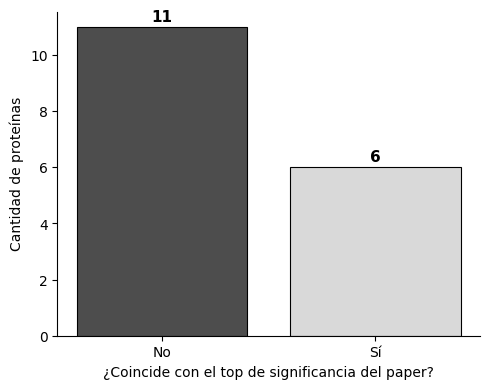

In [ ]:
# figura de proteinas sinteticas que coinciden con paper
conteo = tabla_candidatas["Coincide con proteinas mas significativas del paper"].value_counts()

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(conteo.index, conteo.values, color=["#4d4d4d","#d9d9d9"], edgecolor="black", linewidth=0.8)

for i, valor in enumerate(conteo.values):
    ax.text(i, valor + 0.2, str(valor), ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Cantidad de proteínas", color="black")
ax.set_xlabel("¿Coincide con el top de significancia del paper?", color="black")
ax.tick_params(colors="black")
for etiqueta in ax.get_xticklabels() + ax.get_yticklabels():
    etiqueta.set_color("black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig("figura_panel_final_validacion.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
!pip install python-docx -q
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
# exportar a word para formato apa
documento = Document()

def agregar_titulo_apa(doc, numero, titulo_texto, tipo="Tabla"):
    p1 = doc.add_paragraph(); r1 = p1.add_run(f"{tipo} {numero}")
    r1.bold = True; r1.font.name="Times New Roman"; r1.font.size=Pt(12)
    p2 = doc.add_paragraph(); r2 = p2.add_run(titulo_texto)
    r2.italic = True; r2.font.name="Times New Roman"; r2.font.size=Pt(12)

def agregar_nota_apa(doc, texto_nota):
    p = doc.add_paragraph(); r = p.add_run("Nota. " + texto_nota)
    r.italic = True; r.font.name="Times New Roman"; r.font.size=Pt(10)

def bordes_horizontales(fila_celdas, arriba=False, abajo=False):
    for celda in fila_celdas:
        tc_pr = celda._tc.get_or_add_tcPr()
        bordes = OxmlElement("w:tcBorders")
        for lado, activo in [("top", arriba), ("bottom", abajo)]:
            if activo:
                b = OxmlElement(f"w:{lado}")
                b.set(qn("w:val"), "single"); b.set(qn("w:sz"), "8"); b.set(qn("w:color"), "000000")
                bordes.append(b)
        tc_pr.append(bordes)

def tabla_word_desde_df(doc, df, incluir_indice=False):
    columnas = (["#"] if incluir_indice else []) + list(df.columns)
    t = doc.add_table(rows=1, cols=len(columnas))
    for i, col in enumerate(columnas):
        t.rows[0].cells[i].text = str(col)
        for p in t.rows[0].cells[i].paragraphs:
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(10); r.bold=True
    for idx, fila in df.iterrows():
        celdas = t.add_row().cells
        offset = 0
        if incluir_indice:
            celdas[0].text = str(idx); offset = 1
        for i, col in enumerate(df.columns):
            celdas[i+offset].text = str(fila[col])
        for c in celdas:
            for p in c.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(9)
    bordes_horizontales(t.rows[0].cells, arriba=True)
    bordes_horizontales(t.rows[0].cells, abajo=True)
    bordes_horizontales(t.rows[-1].cells, abajo=True)
    return t

# --- Tabla 5 ---
agregar_titulo_apa(documento, 5, "Panel final de proteínas candidatas a biomarcador pronóstico de progresión de la enfermedad de Chagas")
tabla_word_desde_df(documento, tabla_candidatas_ordenada, incluir_indice=True)
agregar_nota_apa(documento, "Panel obtenido por unión de las proteínas identificadas en el top 10 de importancia por permutación y de coeficientes de regresión logística. La columna derecha indica si la proteína coincide con las de mayor significancia estadística reportadas por Garg et al. (2016).")
documento.add_paragraph()

# --- Figura 5 ---
agregar_titulo_apa(documento, 5, "Validación del panel final de proteínas candidatas contra las proteínas más significativas del estudio de referencia", tipo="Figura")
documento.add_picture("figura_panel_final_validacion.png", width=Pt(300))
agregar_nota_apa(documento, "De las 17 proteínas del panel final, 6 coinciden con las de mayor significancia estadística (menor p-valor) reportadas por Garg et al. (2016).")

documento.save("resultados_objetivo3.docx")
files.download("resultados_objetivo3.docx")
print("Documento del Objetivo 3 generado y descargado ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Documento del Objetivo 3 generado y descargado ✅


In [ ]:
# agregar dirección de cambio y localización subcelular al panel final
# Reconstruimos las columnas numericas de fold-change en la tabla del paper (por si no estaban)
tabla_paper["CA"] = pd.to_numeric(tabla_paper["C/A-vs-N/H"], errors="coerce")
tabla_paper["CS"] = pd.to_numeric(tabla_paper["C/S-vs-N/H"], errors="coerce")
tabla_paper["Spot No."] = pd.to_numeric(tabla_paper["Spot No."], errors="coerce")

# Separamos el nombre de la proteina y el numero de spot en la tabla de candidatas
tabla_candidatas_ordenada[["Nombre_proteina","Spot"]] = tabla_candidatas_ordenada["Proteina"].str.extract(r"^(.*)_spot(\d+)$")
tabla_candidatas_ordenada["Spot"] = pd.to_numeric(tabla_candidatas_ordenada["Spot"], errors="coerce")

# Cruzamos (merge) el panel final con la Localizacion y el fold-change del paper original
tabla_final = tabla_candidatas_ordenada.merge(
    tabla_paper[["Protein name","Spot No.","CS","Localization"]],
    left_on=["Nombre_proteina","Spot"],
    right_on=["Protein name","Spot No."],
    how="left"
)

# Direccion de cambio en base al fold-change de C/S (el grupo de interes: progresion)
tabla_final["Direccion en C/S"] = tabla_final["CS"].apply(
    lambda x: "Aumentada" if x > 0 else ("Disminuida" if x < 0 else "Sin dato")
)

tabla_final_reducida = tabla_final[["Proteina","Localization","Direccion en C/S","Coincide con proteinas mas significativas del paper"]]
tabla_final_reducida = tabla_final_reducida.rename(columns={"Localization":"Localización subcelular"})

tabla_final_reducida

,Proteina,Localización subcelular,Direccion en C/S,Coincide con proteinas mas significativas del paper
0,"Actin, cytoplasmic 1_spot642",NaN,Aumentada,Sí
1,"Keratin, type I cytoskeletal 9_spot863",NaN,Aumentada,Sí
2,"Actin, cytoplasmic 1_spot185",NaN,Disminuida,Sí
3,"Actin, cytoplasmic 1_spot769",CP,Aumentada,Sí
4,"Keratin, type II cytoskeletal 1_spot738",CP,Aumentada,Sí
5,"Actin, cytoplasmic 1_spot781",NaN,Disminuida,Sí
6,POTE ankyrin domain F_spot261,Unknown,Aumentada,No
7,Protein S100-A11_spot878,CP,Disminuida,No
8,Pyruvate kinase M1/M2_spot169,CP,Disminuida,No
9,Ras-related protein Ral-B_spot718,NaN,Aumentada,No


In [ ]:
# Completar Localización con ffill antes del cruce
# Corregimos la Localizacion con el mismo criterio de relleno que usamos para Protein name
tabla_paper["Localization"] = tabla_paper["Localization"].fillna(method="ffill")

# Repetimos el cruce, ahora con la Localizacion ya completa
tabla_final = tabla_candidatas_ordenada.merge(
    tabla_paper[["Protein name","Spot No.","CS","Localization"]],
    left_on=["Nombre_proteina","Spot"],
    right_on=["Protein name","Spot No."],
    how="left"
)

tabla_final["Direccion en C/S"] = tabla_final["CS"].apply(
    lambda x: "Aumentada" if x > 0 else ("Disminuida" if x < 0 else "Sin dato")
)

print("Localizaciones completas ahora:", tabla_final["Localization"].notna().sum(), "de", tabla_final.shape[0])

Localizaciones completas ahora: 17 de 17


/tmp/ipykernel_4358/592403244.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tabla_paper["Localization"] = tabla_paper["Localization"].fillna(method="ffill")


In [ ]:
# tabla de ranking, nombre y localizacion enriquecida
# Asignamos un ranking combinado: en cuantos de los 2 metodos (permutacion, coeficientes) aparece cada proteina
tabla_final["Metodo_permutacion"] = tabla_final["Proteina"].isin(top_permutacion)
tabla_final["Metodo_coeficientes"] = tabla_final["Proteina"].isin(top_nativa)
tabla_final["Cantidad_metodos"] = tabla_final["Metodo_permutacion"].astype(int) + tabla_final["Metodo_coeficientes"].astype(int)

# Diccionario para nombres completos de localizacion (mas legible para la tesis)
nombres_localizacion = {"CP":"Citoplasma", "ES":"Extracelular", "PM":"Membrana plasmática", "NP":"Núcleo", "Unknown":"Desconocida"}
tabla_final["Localización subcelular"] = tabla_final["Localization"].map(nombres_localizacion)

tabla_biologica = tabla_final[[
    "Proteina", "Localización subcelular", "Direccion en C/S",
    "Cantidad_metodos", "Coincide con proteinas mas significativas del paper"
]].rename(columns={
    "Direccion en C/S": "Dirección en C/S",
    "Cantidad_metodos": "N° de métodos que la identifican (máx. 2)",
    "Coincide con proteinas mas significativas del paper": "Respaldo en el paper original"
})

tabla_biologica = tabla_biologica.sort_values(
    ["N° de métodos que la identifican (máx. 2)", "Respaldo en el paper original"],
    ascending=[False, False]
).reset_index(drop=True)
tabla_biologica.index = tabla_biologica.index + 1

tabla_biologica

,Proteina,Localización subcelular,Dirección en C/S,N° de métodos que la identifican (máx. 2),Respaldo en el paper original
1,"Actin, cytoplasmic 1_spot185",Citoplasma,Disminuida,2,Sí
2,"Actin, cytoplasmic 1_spot769",Citoplasma,Aumentada,2,Sí
3,Fibrinogen alpha isoform 2_spot273,Extracelular,Disminuida,2,No
4,"Actin, cytoplasmic 1_spot642",Citoplasma,Aumentada,1,Sí
5,"Keratin, type I cytoskeletal 9_spot863",Citoplasma,Aumentada,1,Sí
6,"Keratin, type II cytoskeletal 1_spot738",Citoplasma,Aumentada,1,Sí
7,"Actin, cytoplasmic 1_spot781",Citoplasma,Disminuida,1,Sí
8,POTE ankyrin domain F_spot261,Desconocida,Aumentada,1,No
9,Protein S100-A11_spot878,Citoplasma,Disminuida,1,No
10,Pyruvate kinase M1/M2_spot169,Citoplasma,Disminuida,1,No


In [ ]:
print("Localización subcelular (sobre 17 proteínas):")
print(tabla_final["Localización subcelular"].value_counts())
print()
print("Dirección de cambio en C/S:")
print(tabla_final["Direccion en C/S"].value_counts())

Localización subcelular (sobre 17 proteínas):
Localización subcelular
Citoplasma             11
Extracelular            3
Desconocida             1
Núcleo                  1
Membrana plasmática     1
Name: count, dtype: int64

Dirección de cambio en C/S:
Direccion en C/S
Aumentada     11
Disminuida     6
Name: count, dtype: int64


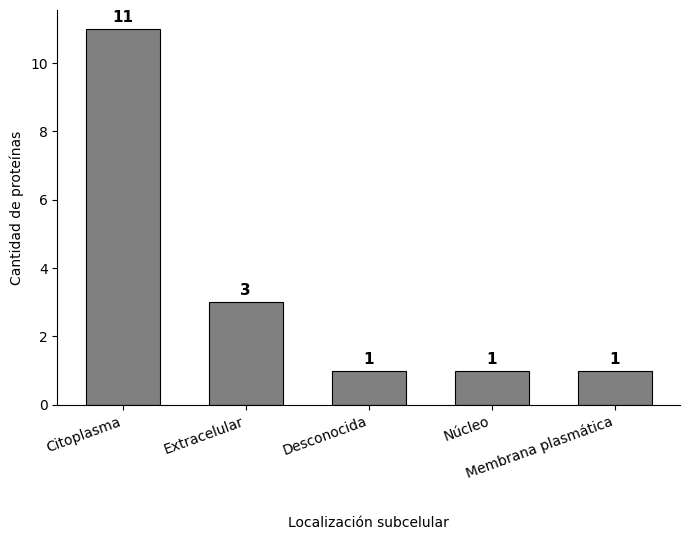

In [ ]:
conteo_localizacion = tabla_final["Localización subcelular"].value_counts()

fig, ax = plt.subplots(figsize=(7,5.5))
ax.bar(conteo_localizacion.index, conteo_localizacion.values,
       color="#808080", edgecolor="black", linewidth=0.8, width=0.6)

for i, valor in enumerate(conteo_localizacion.values):
    ax.text(i, valor + 0.2, str(valor), ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Cantidad de proteínas", color="black")
ax.set_xlabel("Localización subcelular", color="black", labelpad=25)  # mas separacion

ax.tick_params(colors="black")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", color="black")
plt.setp(ax.get_yticklabels(), color="black")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig("figura6_localizacion_panel_final.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# exportar tabla y figura de localizacion proteinas sinteticas candidatas
documento = Document()

def agregar_titulo_apa(doc, numero, titulo_texto, tipo="Tabla"):
    p1 = doc.add_paragraph(); r1 = p1.add_run(f"{tipo} {numero}")
    r1.bold = True; r1.font.name="Times New Roman"; r1.font.size=Pt(12)
    p2 = doc.add_paragraph(); r2 = p2.add_run(titulo_texto)
    r2.italic = True; r2.font.name="Times New Roman"; r2.font.size=Pt(12)

def agregar_nota_apa(doc, texto_nota):
    p = doc.add_paragraph(); r = p.add_run("Nota. " + texto_nota)
    r.italic = True; r.font.name="Times New Roman"; r.font.size=Pt(10)

def bordes_horizontales(fila_celdas, arriba=False, abajo=False):
    for celda in fila_celdas:
        tc_pr = celda._tc.get_or_add_tcPr()
        bordes = OxmlElement("w:tcBorders")
        for lado, activo in [("top", arriba), ("bottom", abajo)]:
            if activo:
                b = OxmlElement(f"w:{lado}")
                b.set(qn("w:val"), "single"); b.set(qn("w:sz"), "8"); b.set(qn("w:color"), "000000")
                bordes.append(b)
        tc_pr.append(bordes)

def tabla_word_desde_df(doc, df, incluir_indice=False):
    columnas = (["#"] if incluir_indice else []) + list(df.columns)
    t = doc.add_table(rows=1, cols=len(columnas))
    for i, col in enumerate(columnas):
        t.rows[0].cells[i].text = str(col)
        for p in t.rows[0].cells[i].paragraphs:
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(10); r.bold=True
    for idx, fila in df.iterrows():
        celdas = t.add_row().cells
        offset = 0
        if incluir_indice:
            celdas[0].text = str(idx); offset = 1
        for i, col in enumerate(df.columns):
            celdas[i+offset].text = str(fila[col])
        for c in celdas:
            for p in c.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for r in p.runs: r.font.name="Times New Roman"; r.font.size=Pt(9)
    bordes_horizontales(t.rows[0].cells, arriba=True)
    bordes_horizontales(t.rows[0].cells, abajo=True)
    bordes_horizontales(t.rows[-1].cells, abajo=True)
    return t

# --- Tabla 6 ---
agregar_titulo_apa(documento, 6, "Panel final de proteínas candidatas a biomarcador, con localización subcelular, dirección del cambio y robustez metodológica")
tabla_word_desde_df(documento, tabla_biologica, incluir_indice=True)
agregar_nota_apa(documento, "N° de métodos: cantidad de técnicas de interpretabilidad (importancia por permutación y coeficientes de regresión logística) que identificaron a la proteína dentro de su top 10. Respaldo en el paper original: coincidencia con las proteínas de mayor significancia estadística reportadas por Garg et al. (2016).")
documento.add_paragraph()

# --- Figura 6 ---
agregar_titulo_apa(documento, 6, "Distribución del panel final de proteínas candidatas según localización subcelular", tipo="Figura")
documento.add_picture("figura6_localizacion_panel_final.png", width=Pt(300))
agregar_nota_apa(documento, "CP = citoplasma; ES = extracelular; PM = membrana plasmática; NP = núcleo. n=17 proteínas.")

documento.save("resultados_objetivo3_final.docx")
files.download("resultados_objetivo3_final.docx")
print("Documento final del Objetivo 3 generado y descargado ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Documento final del Objetivo 3 generado y descargado ✅
